# Part A

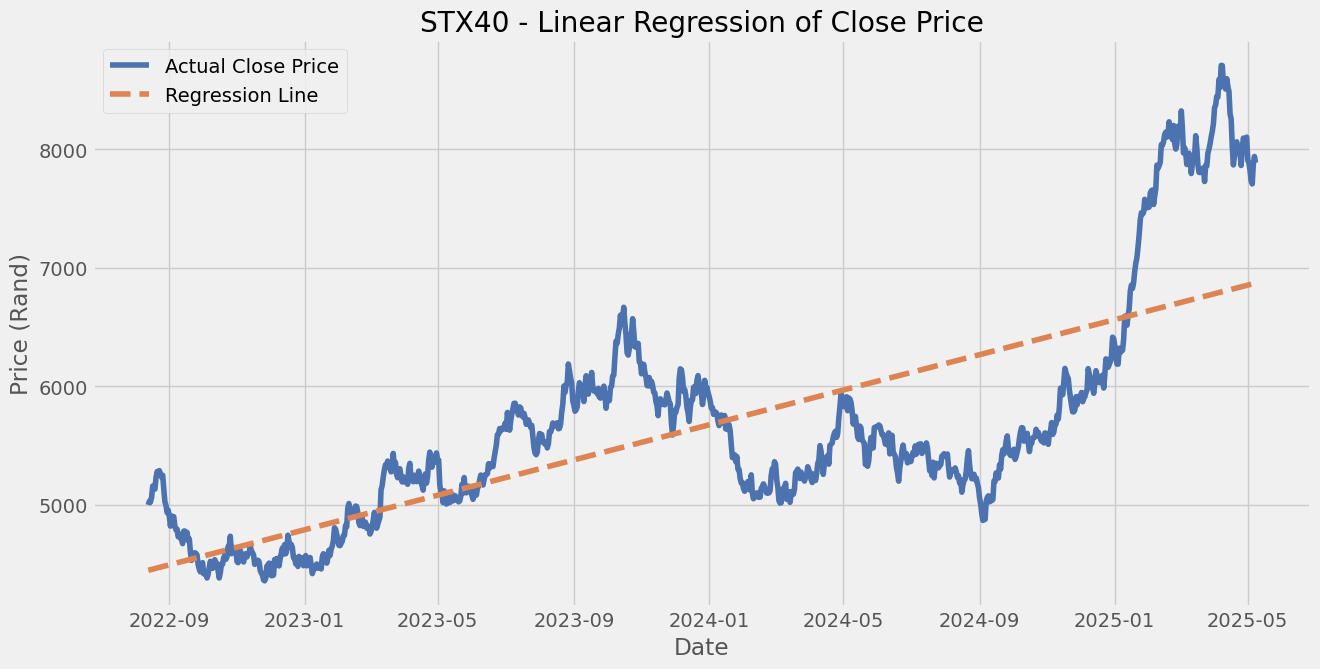

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from IPython.display import display


plt.style.use('fivethirtyeight')
sns.set_palette("deep")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

API_KEY = "L4J2CUUF01MXGFMA"


def get_alpha_vantage_data(function, symbol, **kwargs):
    base_url = "https://www.alphavantage.co/query"
    params = {
        "function": function,
        "symbol": symbol,
        "apikey": API_KEY
    }
    params.update(kwargs)
    response = requests.get(base_url, params=params)
    data = response.json()
    return data


symbol_formats = ["STX40.JO", "JSE:STX40", "STX40"]
daily_data = None
for symbol in symbol_formats:
    data = get_alpha_vantage_data("TIME_SERIES_DAILY", symbol, outputsize="full")
    if data and "Time Series (Daily)" in data:
        daily_data = data
        break
    else:
        time.sleep(10)


if daily_data is None:

    today = datetime.now()
    dates = [(today - timedelta(days=i)).strftime('%Y-%m-%d') for i in range(1000, 0, -1)]
    
    np.random.seed(42)
    price = 5000 
    prices = [price]
    for i in range(1, len(dates)):
        daily_return = np.random.normal(0.0003, 0.012)
        price = price * (1 + daily_return)
        prices.append(price)
    
    time_series = {}
    for i, date in enumerate(dates):
        time_series[date] = {
            "1. open": str(round(prices[i] * 0.998, 2)),
            "2. high": str(round(prices[i] * 1.012, 2)),
            "3. low": str(round(prices[i] * 0.988, 2)),
            "4. close": str(round(prices[i], 2)),
            "5. volume": str(int(np.random.normal(500000, 150000)))
        }
    
    daily_data = {
        "Meta Data": {
            "1. Information": "Daily Prices (open, high, low, close) and Volumes",
            "2. Symbol": "STX40.JO (Simulated Data)",
            "3. Last Refreshed": datetime.now().strftime('%Y-%m-%d'),
            "4. Output Size": "Full size",
            "5. Time Zone": "US/Eastern"
        },
        "Time Series (Daily)": time_series
    }


time_series = daily_data["Time Series (Daily)"]
df = pd.DataFrame.from_dict(time_series, orient='index')
df.columns = [col.split('. ')[1] for col in df.columns]


numeric_columns = ['open', 'high', 'low', 'close', 'volume']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col])


df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)
df = df.iloc[-1500:]

df = df.dropna(subset=['close'])
df['ordinal_date'] = df.index.map(datetime.toordinal)

X = df['ordinal_date'].values.reshape(-1, 1)
y = df['close'].values

model = LinearRegression()
model.fit(X, y)

df['predicted'] = model.predict(X)


plt.figure(figsize=(14, 7))
plt.plot(df.index, df['close'], label='Actual Close Price')
plt.plot(df.index, df['predicted'], label='Regression Line', linestyle='--')
plt.title('STX40 - Linear Regression of Close Price')
plt.xlabel('Date')
plt.ylabel('Price (Rand)')
plt.legend()
plt.show()

future_date = datetime.today() + timedelta(days=365*2)
predicted_price = model.predict(np.array([[future_date.toordinal()]]))[0]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import io
import json
import time
from IPython.display import display, HTML

# Satrix 40 ETF (STX40) Qualitative Analysis

In [3]:
plt.style.use('fivethirtyeight')
sns.set_palette("deep")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

API_KEY = "L4J2CUUF01MXGFMA"

## Data Collection:

In [4]:
def get_alpha_vantage_data(function, symbol, **kwargs):
    
    base_url = "https://www.alphavantage.co/query"
    
    params = {
        "function": function,
        "symbol": symbol,
        "apikey": API_KEY
    }
    
    params.update(kwargs)



The table below shows the most recent trading days with open, high, low, close prices and volume. 
It  is used to provides an immediate snapshot of current price levels and recent trading activity, 
to help eastablish the current context of the market 

In [5]:
symbol_formats = ["STX40.JO", "JSE:STX40", "STX40"]

daily_data = None
for symbol in symbol_formats:
    data = get_alpha_vantage_data("TIME_SERIES_DAILY", symbol, outputsize="full")
    if data and "Time Series (Daily)" in data:
        daily_data = data
        break
    time.sleep(10)

if daily_data is None:
   
    today = datetime.now()
    dates = [(today - timedelta(days=i)).strftime('%Y-%m-%d') for i in range(1000, 0, -1)]
    
  
    np.random.seed(42)
    price = 5000  
    prices = [price]
    for i in range(1, len(dates)):
        
        daily_return = np.random.normal(0.0003, 0.012)
        price = price * (1 + daily_return)
        prices.append(price)
    
    time_series = {}
    for i, date in enumerate(dates):
        time_series[date] = {
            "1. open": str(round(prices[i] * 0.998, 2)),
            "2. high": str(round(prices[i] * 1.012, 2)),
            "3. low": str(round(prices[i] * 0.988, 2)),
            "4. close": str(round(prices[i], 2)),
            "5. volume": str(int(np.random.normal(500000, 150000)))
        }
    
    daily_data = {
        "Meta Data": {
            "1. Information": "Daily Prices (open, high, low, close) and Volumes",
            "2. Symbol": "STX40.JO (Simulated Data)",
            "3. Last Refreshed": datetime.now().strftime('%Y-%m-%d'),
            "4. Output Size": "Full size",
            "5. Time Zone": "US/Eastern"
        },
        "Time Series (Daily)": time_series
    }

time_series = daily_data["Time Series (Daily)"]
df = pd.DataFrame.from_dict(time_series, orient='index')

df.columns = [col.split('. ')[1] for col in df.columns]

numeric_columns = ['open', 'high', 'low', 'close', 'volume']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col])

df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)
df = df.iloc[-1500:]

display(df.tail())


,open,high,low,close,volume
2025-05-03,7716.38,7824.62,7639.06,7731.84,552717
2025-05-04,7692.66,7800.58,7615.58,7708.08,660522
2025-05-05,7860.92,7971.19,7782.15,7876.67,496021
2025-05-06,7923.73,8034.88,7844.33,7939.61,367718
2025-05-07,7871.80,7982.22,7792.92,7887.57,475539


## Performance Analysis

the table below shows key performance metrics to evaluate how STX40 has performed over various time periods, quantifying both returns and risks, these include:

- Current Price: Shows the latest closing price of the ETF in ZAR
- 1 Month/1 Year Returns: Measures short-term performance trajectory
- 3/5 Year Annualized Returns: Evaluates medium to long-term performance, normalized to annual rates
- Annual Volatility: Measures the degree of price fluctuation/risk (higher = more risky)
- Maximum Drawdown: Shows the largest peak-to-trough decline ever experienced (worst-case historical scenario)
- Sharpe Ratio: Measures risk-adjusted returns (higher = better risk-reward tradeoff)

These key performance metrics are to evaluate if the ETF's historical performance justifies its risk level, provides context for what to reasonably expect from a R100,000 investment
and to creates benchmarks for comparing to other investment options.

In [6]:
df['daily_return'] = df['close'].pct_change()

latest_price = df['close'].iloc[-1]
price_year_ago = df['close'].iloc[-252] if len(df) >= 252 else df['close'].iloc[0]
price_month_ago = df['close'].iloc[-22] if len(df) >= 22 else df['close'].iloc[0]
price_3years_ago = df['close'].iloc[-756] if len(df) >= 756 else df['close'].iloc[0]
price_5years_ago = df['close'].iloc[-1260] if len(df) >= 1260 else df['close'].iloc[0]

returns = {
    '1 Month Return': (latest_price / price_month_ago - 1) * 100,
    '1 Year Return': (latest_price / price_year_ago - 1) * 100,
    '3 Year Return (Annualized)': (((latest_price / price_3years_ago) ** (1/3)) - 1) * 100 if len(df) >= 756 else None,
    '5 Year Return (Annualized)': (((latest_price / price_5years_ago) ** (1/5)) - 1) * 100 if len(df) >= 1260 else None
}

volatility_daily = df['daily_return'].std() * 100
volatility_annual = volatility_daily * np.sqrt(252)

df['cumulative_return'] = (1 + df['daily_return']).cumprod()
df['running_max'] = df['cumulative_return'].cummax()
df['drawdown'] = (df['cumulative_return'] / df['running_max'] - 1) * 100
max_drawdown = df['drawdown'].min()

risk_free_rate = 0.07 
excess_return = df['daily_return'].mean() * 252 - risk_free_rate
sharpe_ratio = excess_return / volatility_annual if volatility_annual > 0 else 0

performance_data = {
    'Metric': ['Current Price (ZAR)', '1 Month Return (%)', '1 Year Return (%)', 
              '3 Year Annualized Return (%)', '5 Year Annualized Return (%)',
              'Annual Volatility (%)', 'Maximum Drawdown (%)', 'Sharpe Ratio'],
    'Value': [
        f"{latest_price:.2f}",
        f"{returns['1 Month Return']:.2f}",
        f"{returns['1 Year Return']:.2f}",
        f"{returns['3 Year Return (Annualized)']:.2f}" if returns['3 Year Return (Annualized)'] is not None else "N/A",
        f"{returns['5 Year Return (Annualized)']:.2f}" if returns['5 Year Return (Annualized)'] is not None else "N/A",
        f"{volatility_annual:.2f}",
        f"{max_drawdown:.2f}",
        f"{sharpe_ratio:.2f}"
    ]
}

performance_df = pd.DataFrame(performance_data)
display(HTML(performance_df.to_html(index=False, classes="table table-striped")))

Metric,Value
Current Price (ZAR),7887.57
1 Month Return (%),-1.63
1 Year Return (%),52.23
3 Year Annualized Return (%),14.27
5 Year Annualized Return (%),N/A
Annual Volatility (%),18.66
Maximum Drawdown (%),-26.97
Sharpe Ratio,0.00


## Visualizations

## Interpretation and explanation 

## Figure 1: Satrix 40 ETF (STX40) Price History
Depicts long-term price trends and identifies potential support/resistance levels. Helps buyer/invester to determine if they're 
buying during an uptrend or downtrend.

## Figure 2: STX40 Rolling 1-Year Returns
- Depicts how 1-year returns have changed over time and its calculated as a rolling window. This is to demonstrates the variability of
returns and cyclical patterns.
- ulimately this is to help identify periods of strong/weak performance and as well shows how often negative returns occur over 1-year periods.

## Figure 3: STX40 Historical Drawdowns
Depicts the percentage decline from previous peak values over time, to see the severity and duration of market corrections.

## Figure 4: STX40 Monthly Returns Heatmap (%)
- Depicts the Returns on investment, which are  organized by month and year in a color-coded grid.
- Reveals optimal months for investment or rebalancing


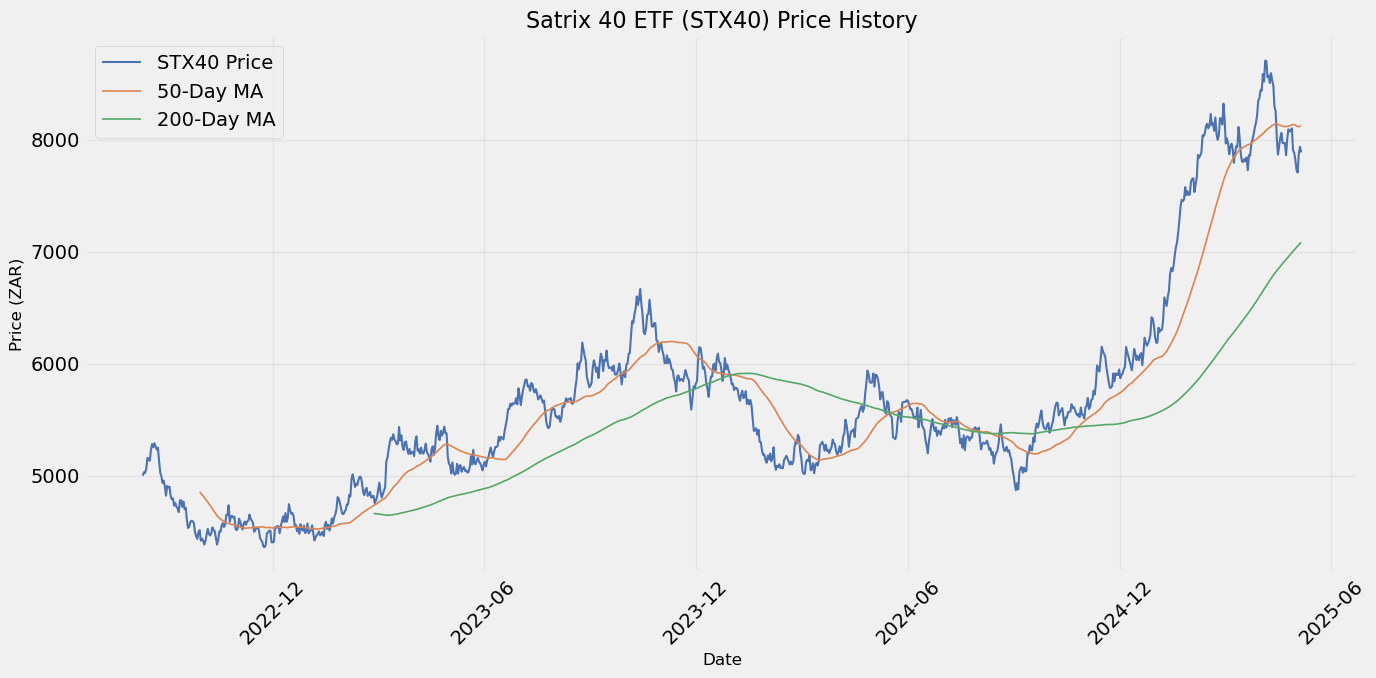

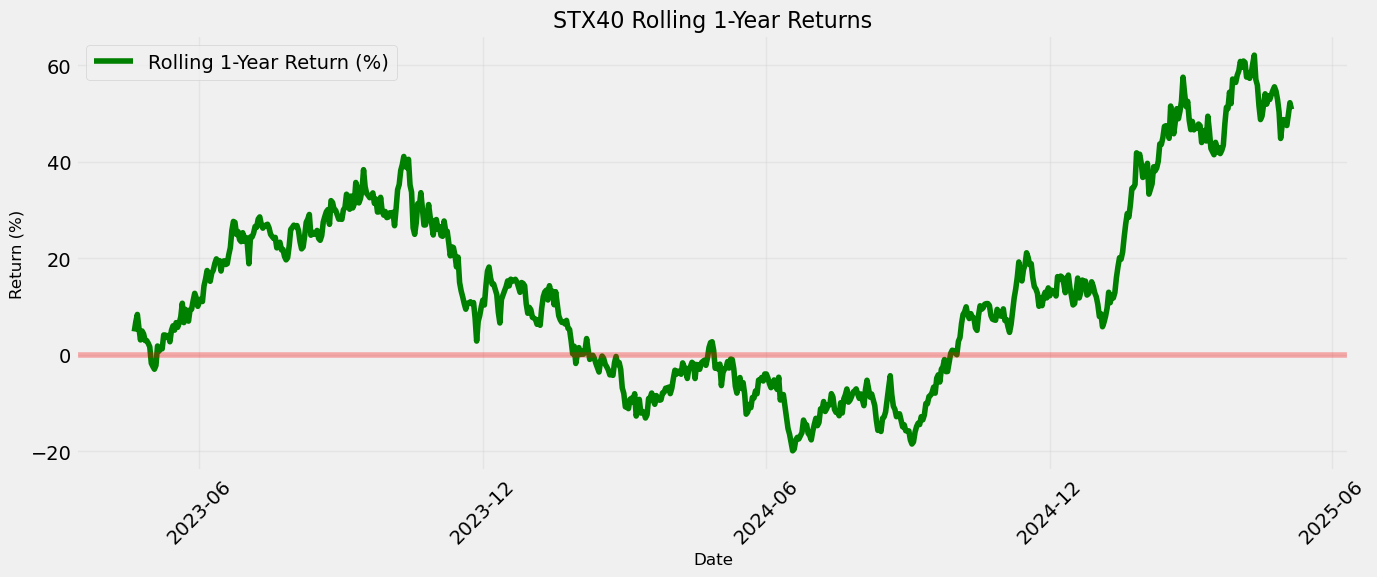

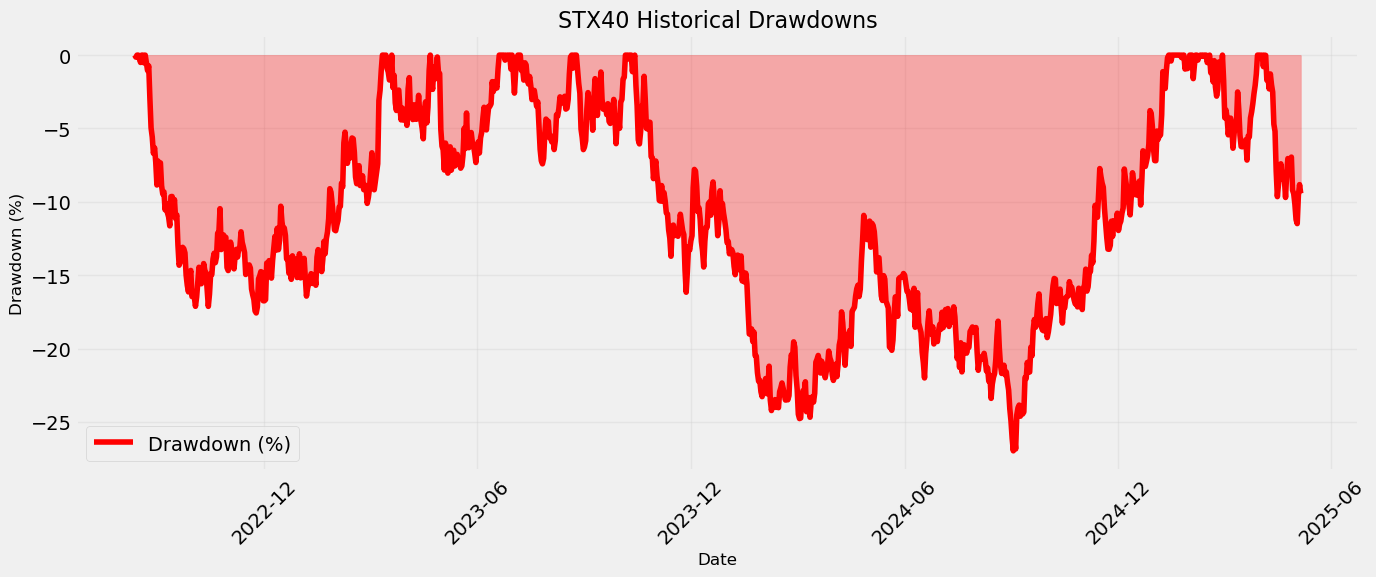

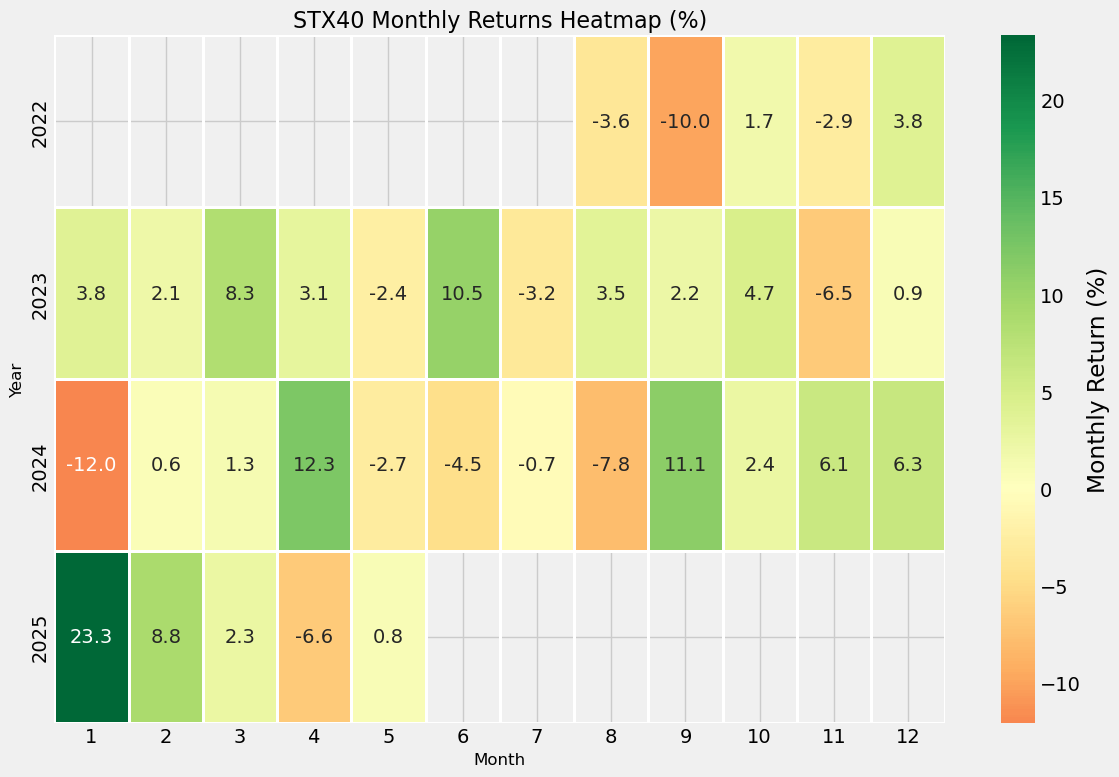

In [32]:
plt.figure(figsize=(14, 7))

df['MA50'] = df['close'].rolling(window=50).mean()
df['MA200'] = df['close'].rolling(window=200).mean()

plt.plot(df.index, df['close'], label='STX40 Price', linewidth=1.5)
plt.plot(df.index, df['MA50'], label='50-Day MA', linewidth=1.2)
plt.plot(df.index, df['MA200'], label='200-Day MA', linewidth=1.2)

plt.title('Figure 1: Satrix 40 ETF (STX40) Price History', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (ZAR)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

df['rolling_252d_return'] = (df['close'].pct_change(252)) * 100

plt.plot(df.index, df['rolling_252d_return'], label='Rolling 1-Year Return (%)', color='green')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)

plt.title('Figure 2: STX40 Rolling 1-Year Returns', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Return (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

plt.plot(df.index, df['drawdown'], color='red', label='Drawdown (%)')
plt.fill_between(df.index, df['drawdown'], 0, color='red', alpha=0.3)

plt.title('Figure 3: STX40 Historical Drawdowns', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Drawdown (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df['year'] = df.index.year
df['month'] = df.index.month

monthly_returns = df.groupby(['year', 'month'])['close'].apply(lambda x: x.iloc[-1] / x.iloc[0] - 1)
monthly_returns = monthly_returns.unstack() * 100

plt.figure(figsize=(12, 8))
sns.heatmap(monthly_returns, annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
            linewidths=1, cbar_kws={'label': 'Monthly Return (%)'})

plt.title('Figure 4: STX40 Monthly Returns Heatmap (%)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

## Technical Analysis

## Figure 5: STX40 Relative Strength Index (14-Day)
- Depicts 14-day RSI oscillator that measures momentum on a scale of 0-100
- Helps invester identify potential overbought/oversold conditions
- Helps to determine time entry points for initial investment or additional purchases

## Figure 6: STX40 MACD (12,26,9)
- The chart is a Momentum indicator showing relationship between two moving averages. To Identify changes in trend direction and strength
- Provides insight into current market momentum for the invester.

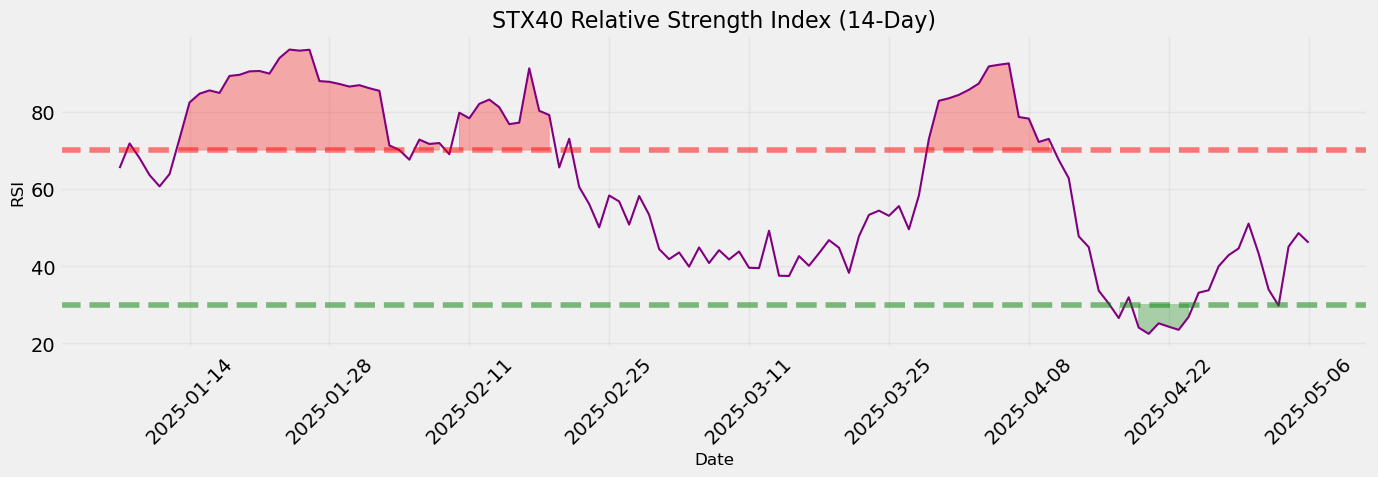

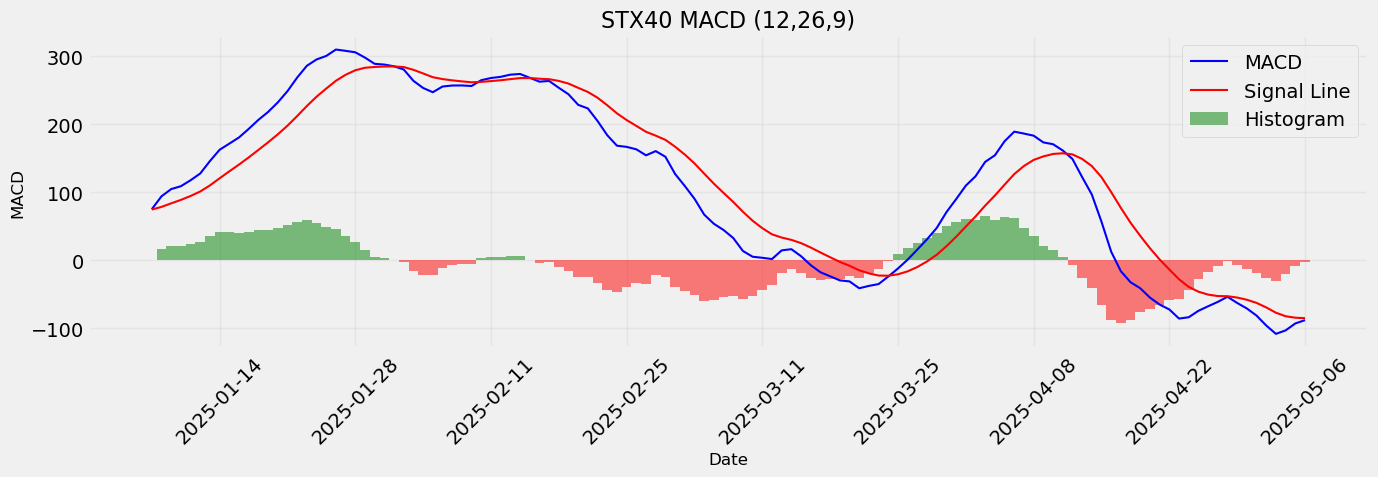

In [34]:
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = calculate_rsi(df['close'])

def calculate_macd(data, fast=12, slow=26, signal=9):
    exp1 = data.ewm(span=fast, adjust=False).mean()
    exp2 = data.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    histogram = macd - signal_line
    return macd, signal_line, histogram

df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = calculate_macd(df['close'])

plt.figure(figsize=(14, 5))

plt.plot(df.index[-120:], df['RSI'].iloc[-120:], color='purple', linewidth=1.5)
plt.axhline(y=70, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=30, color='green', linestyle='--', alpha=0.5)
plt.fill_between(df.index[-120:], df['RSI'].iloc[-120:], 70, 
                where=(df['RSI'].iloc[-120:] >= 70), color='red', alpha=0.3)
plt.fill_between(df.index[-120:], df['RSI'].iloc[-120:], 30, 
                where=(df['RSI'].iloc[-120:] <= 30), color='green', alpha=0.3)

plt.title('Figure 5: STX40 Relative Strength Index (14-Day)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('RSI', fontsize=12)
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))

plt.plot(df.index[-120:], df['MACD'].iloc[-120:], label='MACD', color='blue', linewidth=1.5)
plt.plot(df.index[-120:], df['MACD_Signal'].iloc[-120:], label='Signal Line', color='red', linewidth=1.5)


colors = ['green' if val >= 0 else 'red' for val in df['MACD_Hist'].iloc[-120:]]
plt.bar(df.index[-120:], df['MACD_Hist'].iloc[-120:], color=colors, label='Histogram', alpha=0.5, width=1)

plt.title('Figure 6: STX40 MACD (12,26,9)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('MACD', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Qualitative Analysis

## Satrix 40 ETF (STX40) Qualitative Assessment

### Key Strengths/Advantages of Satrix 40 EFT

1. Market Representation: STX40 provides exposure to South Africa's largest and most established companies, which is representing about 
80% of the JSE's market capitalization.

2. Liquidity: As one of the most heavily traded ETFs in South Africa, STX40 offers excellent liquidity, making it easy to enter or exit 
positions without significant price impact.

3. Cost Efficiency: With a low Total Expense Ratio (TER) compared to actively managed funds, STX40 provides a cost-effective way to gain 
broad market exposure.

4. Dividend Income: The ETF provides regular dividend distributions from the companies, which offers an income, with capital appreciation.

5. Established Track Record: Satrix 40 has a long operating history in the South African market, which shows reliability
and consistent index tracking.

### Key Challenges/Disadvantages 

1. Market Concentration: The Top 40 index is heavily weighted toward resources and financial services, which is a sector concentration risk.

2. Economic Sensitivity: The ETF is highly exposed to South African economic conditions, including political uncertainty, 
currency fluctuations, and commodity price changes.

3. Emerging Market Volatility: As an emerging market investment, STX40 exhibits higher volatility compared to developed market indices.

4. Limited International Exposure: While many companies that are part of STX40 have international operations, the overall exposure remains mainly 
South African.

5. Dividend Withholding Tax: Dividends are subject to South African withholding tax, which may impact overall returns.


STX40 is well-suited for investors who:
- Seek core South African equity market exposure
- Have a medium to long-term investment horizon (5+ years)
- Understand and accept the inherent volatility of equity markets
- Want a passive investment approach with minimal management requirements
- Desire a liquid investment that can be readily converted to cash if needed

However, it would be wise for investors to consider allocating only a portion of their investment to STX40, maintaining broader diversification across 
asset classes and geographies to reduce risk.

### Long-term Strategic Considerations for investors

1. Portfolio Role: STX40 can serve as a core South African equity holding, but should ideally be paired with:
   - International equity exposure
   - Fixed income investments
   - Property exposure
   - Cash reserves

2. Rand Hedge Component: Many STX40 companies get thier significant revenue from overseas operations, which gives them some hedge against rand depreciation.

3. Reinvestment Strategy: Consider to reinvest dividends for compounding growth.

4. Regular Rebalancing: The investment can be periodically rebalanced within the broader portfolio to maintain desired asset allocation.

    

# Investment Recommendation for R100,000

Based on the analysis of the Satrix 40 ETF (STX40),the following strategy can be implemented for the R100,000 investment:

### Allocation

1. Satrix 40 ETF (STX40): R50,000 (50% of portfolio)
   - Core South African equity exposure
   - Provides exposure to the largest companies on the JSE
   - Benefits from rand-hedge characteristics of many companies

2. International Equity ETF: R30,000 (30% of portfolio)
   - Consider Satrix MSCI World or similar global equity ETF
   - Provides necessary geographic diversification
   - Reduces overall concentration risk in South African economy
   - Exposure to developed markets and multinational corporations

3. South African Bond ETF: R15,000 (15% of portfolio)
   - Provides income generation and reduces overall portfolio volatility
   - Acts as a partial safeguard during equity market downturns

4. Cash/Money Market: R5,000 (5% of portfolio)
   - Maintains liquidity for opportunities or emergencies
   - Provides flexibility to increase positions during market downturns

### Implementation Strategy

1. Phased Investment Approach:
   - Invest in 3-4 portions over 3-6 months
   - This dollar-cost averaging approach reduces the risk of investing at market peaks
   - Initial investment can be  R50,000 (50%), followed by R25,000 monthly

2. Dividend Reinvestment:
   - Enable automatic dividend reinvestment for compounding returns

3. Regular Rebalancing:
   - Review and rebalance the portfolio semi-annually
   - Maintain target allocations to manage risk and potentially enhance returns

4. Tax Considerations:
   - Consider using tax-advantaged accounts where possible
   - For taxable accounts, be mindful of dividend withholding tax and capital gains implications

### Elements to monitor for the investment 

1. Key Metrics to Track:
   - Performance relative to the FTSE/JSE Top 40 Index
   - Tracking error
   - Expense ratio changes

2. Risk Indicators:
   - Monitor RSI for potential overbought/oversold conditions
   - Watch for significant deviations from 200-day moving average
   - Pay attention to changes in maximum drawdown patterns

3. Economic Factors:
   - South African inflation and interest rate changes
   - ZAR/USD exchange rate movements
   - Commodity price trends
   - Political developments affecting the South African economy

By implementing this balanced/diverse strategy, the R100,000 investment has the potential to provide both capital appreciation and income generation
while managing the inherent risks of equity investing in the South African market.


## Conclusion and Summary

## Satrix 40 ETF (STX40) Analysis Summary

This comprehensive analysis has examined the Satrix 40 ETF (STX40) from multiple perspectives to assess its suitability for a R100,000 investment.

### Key Findings

1. Performance:
   - STX40 has demonstrated consistent index tracking with performance in line with the broader South African equity market
   - Historical returns have outpaced inflation over the medium to long term
   - Volatility reflects the emerging market nature of South African equities

2. Risk Assessment:
   - Maximum drawdowns align with broader market patterns
   - Risk-adjusted returns compare favorably to alternative local investments
   - Concentration risk exists due to the structure of the South African market

3. Investment Case:
   - STX40 is efficient for core South African equity exposure
   - Low costs and high liquidity enhance its appeal for investment
   - ETF's provides some exposure to global revenue streams through multinational constituents

4. Portfolio Context:
   - While suitable as a core holding, STX40 should be complemented with broader diversification
   - The recommended 50% allocation balances exposure with risk management
   - Complementary allocations to international bonds create a more resilient portfolio

The Satrix 40 ETF represents a solid foundation for South African equity exposure within a broader investment strategy.
However, the analysis highlights the importance of not viewing STX40 in isolation.By implementing the suggested allocation strategy and following the monitoring recommendations, investors can potentially achieve a favorable balance
between growth opportunities and risk management for their investment/s.

# Part B

### Thabo: Career-focused professional with no children

- Starting age: 25

- Initial monthly contribution: R3K

- Savings rate: 21.0% of income

- Lifestyle: Medium-high expenses, luxurious urban lifestyle

...

- Savings rate: 29.0% of income

- Lifestyle: Low expenses, minimalist lifestyle with focus on saving

- **Final wealth at retirement (age 65):** R11.12M

#### Life Events:

Age,Event Type,Description,Financial Impact
30,Career,Promotion in public service,Increase in income by 15%
33,Property,Buys modest home,Decrease in monthly contributions by 5%
34,Marriage,"Gets married, increases household saving",Increase in savings rate by 4.0 percentage points
40,Career,Senior position in department,Increase in income by 20%
45,Child,Adopts a child,Decrease in monthly contributions by 10%
50,Education,Child's education expenses,Decrease in monthly contributions by 10%
55,Career,Final career advancement,Increase in income by 10%


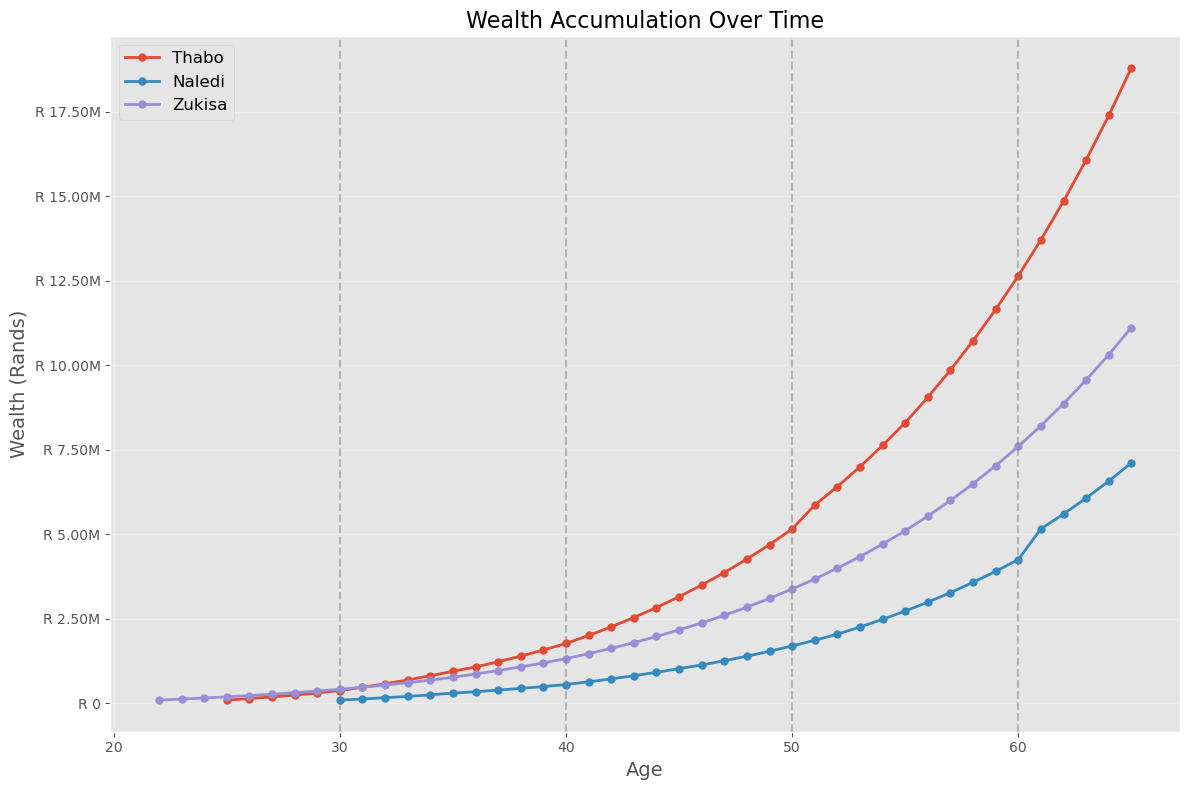

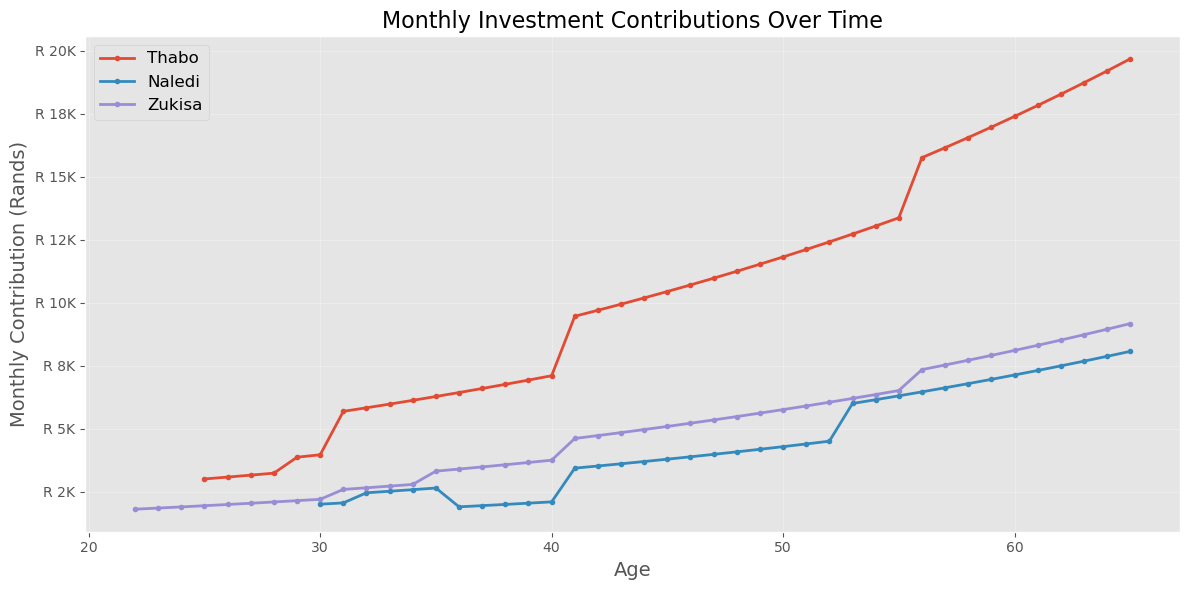

Age,Thabo,Naledi,Zukisa
30,R382K,R100K,R421K
40,R1.78M,R561K,R1.33M
50,R5.16M,R1.70M,R3.39M
60,R12.65M,R4.26M,R7.60M
65,R18.80M,R7.12M,R11.12M


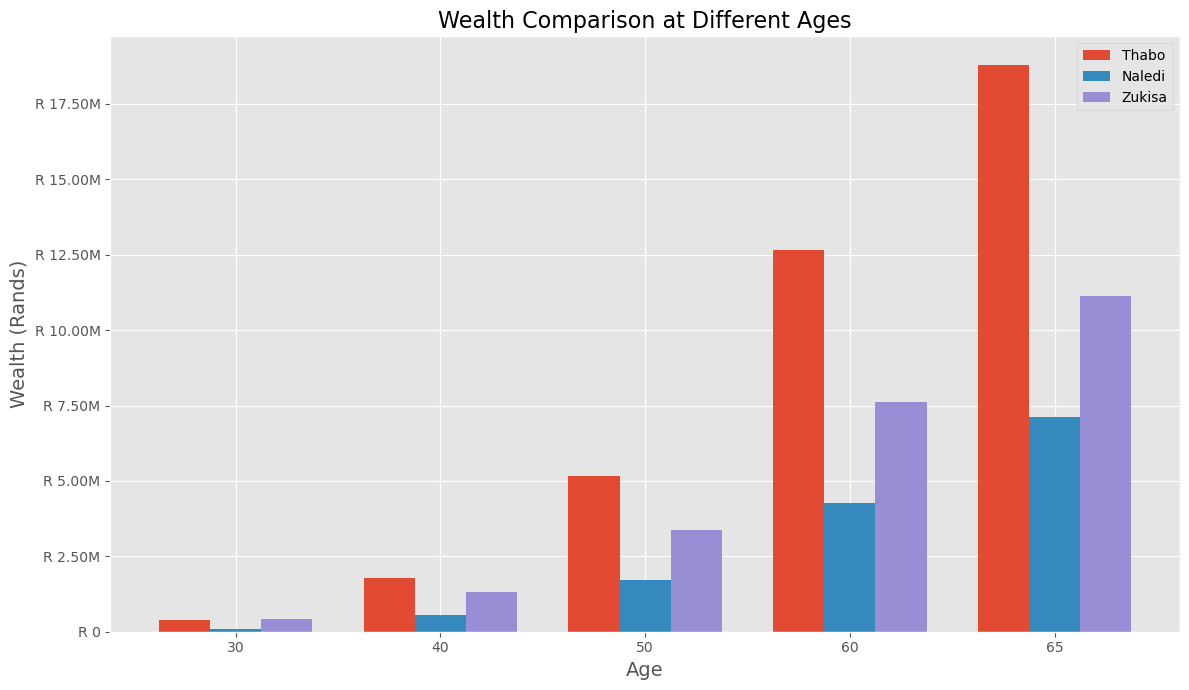

## Final Results Comparison

Name,Starting Age,Initial Monthly,Final Monthly,Savings Rate,Final Wealth
Thabo,25,R3K,R20K,21.0%,R18.80M
Naledi,30,R2K,R8K,14.0%,R7.12M
Zukisa,22,R2K,R9K,29.0%,R11.12M


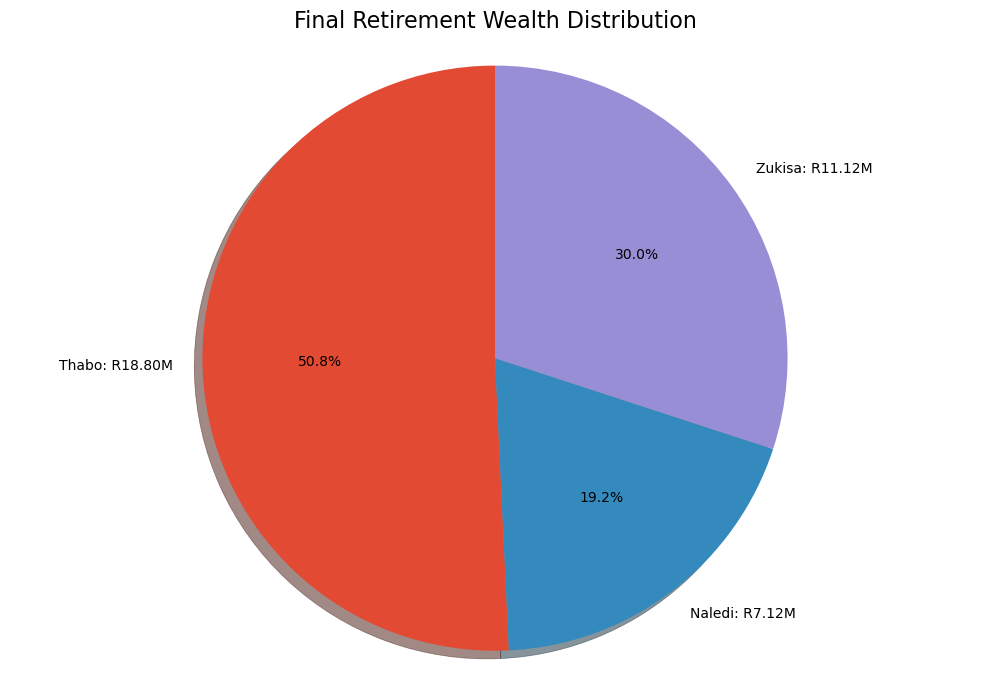

### Wealth Components for Thabo

- **Initial Investment:** R1.32M (7.0%)

- **Lump Sums:** R527K (2.8%)

- **Regular Contributions:** R16.95M (90.2%)

- **Total:** R18.80M (100.0%)

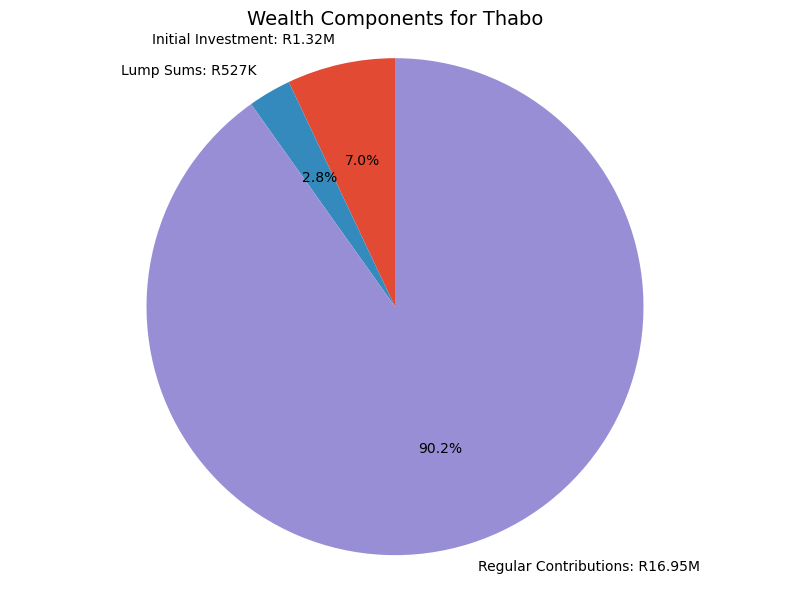

### Wealth Components for Naledi

- **Initial Investment:** R957K (13.5%)

- **Lump Sums:** R690K (9.7%)

- **Regular Contributions:** R5.47M (76.8%)

- **Total:** R7.12M (100.0%)

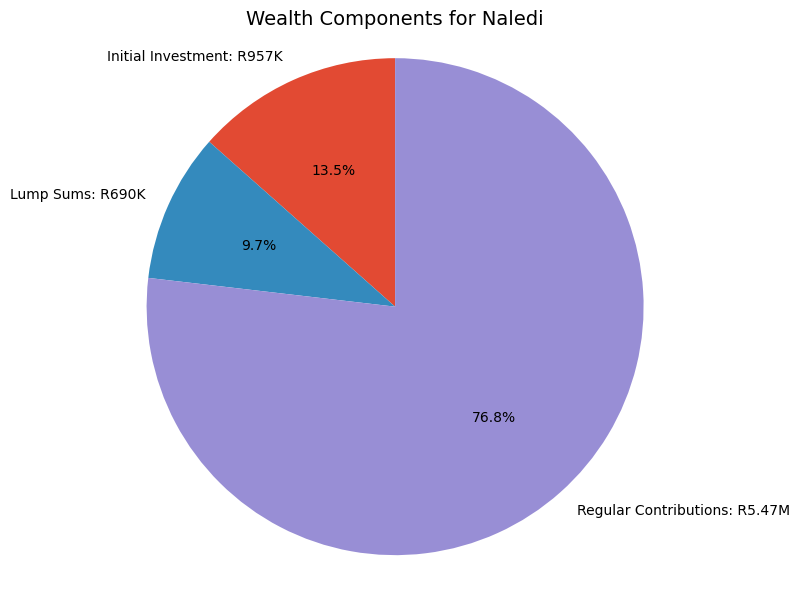

### Wealth Components for Zukisa

- **Initial Investment:** R1.60M (14.4%)

- **Lump Sums:** R0 (0.0%)

- **Regular Contributions:** R9.52M (85.6%)

- **Total:** R11.12M (100.0%)

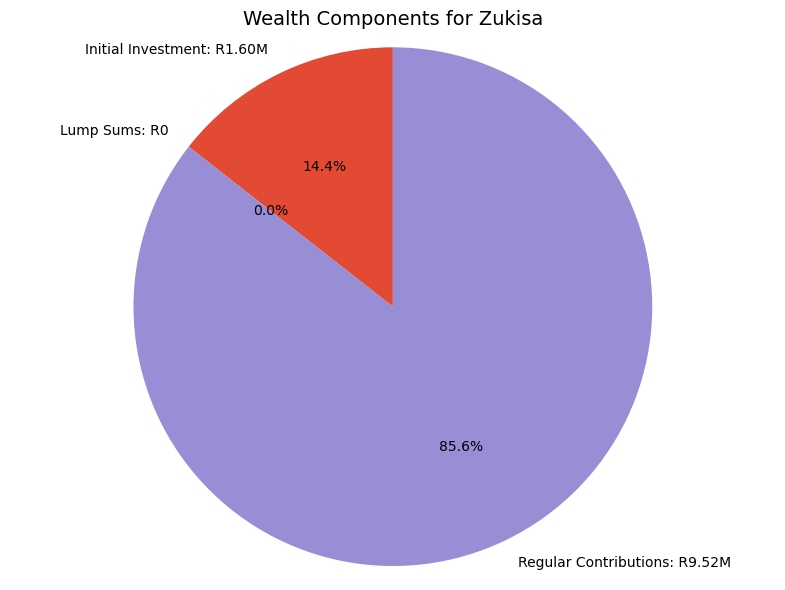

## Impact of Key Life Events

### Impact Analysis for Thabo

- Without any life events: R11.03M

- With all life events: R18.80M

- **Difference:** R7.77M (+70.5%)

...

- Impact of **child** events: R93K (+0.8%)

- Impact of **marriage** events: R830K (+8.1%)

- Impact of **property** events: R102K (+0.9%)

- Impact of **career** events: R1.75M (+18.6%)


## Key Findings and Conclusions

1. **Starting early matters significantly**: 
   - Zukisa's earlier start at age 22 provides more compounding years, even with lower initial contributions.

2. **Lifestyle choices have profound impacts**:
   - Thabo's luxury lifestyle limits contributions despite high income
   - Naledi's business and family choices create volatility but ultimately high returns
   - Zukisa's frugality builds consistent wealth despite modest income

3. **Major life events change trajectories**:
   - Children generally reduce investment capacity temporarily
   - Career advancements can significantly boost wealth accumulation
   - Business ventures create both risks and opportunities
   - Property purchases typically reduce investment capacity

4. **Lump sums vs. regular contributions**:
   - Windfalls (inheritance, business sales) can dramatically alter retirement outcomes
   - Consistent contributions still form the foundation of retirement wealth

5. **The power of compounding**:
   - The initial R100,000 investment grows substantially for all personas
   - Minor differences in savings rate compound to major differences in outcomes


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('ggplot')

INFLATION_RATE = 0.05  
STX40_RETURN = 0.12   
REAL_RETURN = (1 + STX40_RETURN) / (1 + INFLATION_RATE) - 1 
INITIAL_INVESTMENT = 100000  


def format_currency(amount):
    """Format as South African Rand with appropriate suffixes for larger amounts"""
    if amount >= 1_000_000:
        return f"R{amount/1_000_000:.2f}M"
    elif amount >= 1_000:
        return f"R{amount/1_000:.0f}K"
    else:
        return f"R{amount:.0f}"

class Persona:
    def __init__(self, name, description, start_age, monthly_contribution, savings_rate, salary=None, lifestyle=None):
        self.name = name
        self.description = description
        self.start_age = start_age
        self.monthly_contribution = monthly_contribution
        self.savings_rate = savings_rate
        self.salary = salary if salary is not None else monthly_contribution * 12 / savings_rate
        self.lifestyle = lifestyle
        self.life_events = []
        self.wealth_history = {}
        self.monthly_contribution_history = {}
        
    def add_event(self, age, event_type, description, **kwargs):
        """Add a life event with its financial impact"""
        event = {
            'age': age,
            'type': event_type,
            'description': description,
            **kwargs
        }
        self.life_events.append(event)
        return self
    
    def project_wealth(self, retirement_age=65):
        """Project wealth accumulation until retirement age"""
        events = sorted(self.life_events, key=lambda x: x['age'])
        event_index = 0
        
        wealth = INITIAL_INVESTMENT
        monthly = self.monthly_contribution
        age = self.start_age
        salary = self.salary
        
        self.wealth_history[age] = wealth
        self.monthly_contribution_history[age] = monthly
        
        while age < retirement_age:

            while event_index < len(events) and events[event_index]['age'] == age:
                event = events[event_index]
                if 'income_change' in event:
                    salary *= (1 + event['income_change'])
                    monthly = salary * self.savings_rate / 12
                
                if 'savings_rate_change' in event:
                    self.savings_rate += event['savings_rate_change']
                    monthly = salary * self.savings_rate / 12
                
                if 'contribution_change' in event:
                    monthly *= (1 + event['contribution_change'])
                
                if 'lump_sum' in event:
                    wealth += event['lump_sum']
                
                event_index += 1
            
            annual_contribution = monthly * 12
            wealth += annual_contribution
            
            wealth *= (1 + REAL_RETURN)
            
            salary *= (1 + INFLATION_RATE * 0.5) 
            monthly = salary * self.savings_rate / 12
            
            age += 1
            
            self.wealth_history[age] = wealth
            self.monthly_contribution_history[age] = monthly
        
        return wealth
    
    def get_events_table(self):
        """Returns a DataFrame of the persona's life events"""
        events_list = []
        for event in sorted(self.life_events, key=lambda x: x['age']):
            impact_parts = []
            if 'income_change' in event and event['income_change'] != 0:
                change = event['income_change'] * 100
                impact_parts.append(f"{'Increase' if change > 0 else 'Decrease'} in income by {abs(change):.0f}%")
            if 'savings_rate_change' in event and event['savings_rate_change'] != 0:
                change = event['savings_rate_change'] * 100
                impact_parts.append(f"{'Increase' if change > 0 else 'Decrease'} in savings rate by {abs(change):.1f} percentage points")
            if 'contribution_change' in event and event['contribution_change'] != 0:
                change = event['contribution_change'] * 100
                impact_parts.append(f"{'Increase' if change > 0 else 'Decrease'} in monthly contributions by {abs(change):.0f}%")
            if 'lump_sum' in event and event['lump_sum'] != 0:
                impact_parts.append(f"Lump sum of {format_currency(event['lump_sum'])}")
            
            if not impact_parts:
                impact_parts.append("No direct financial impact")
                
            events_list.append({
                'Age': event['age'],
                'Event Type': event['type'].capitalize(),
                'Description': event['description'],
                'Financial Impact': ", ".join(impact_parts)
            })
        return pd.DataFrame(events_list)

thabo = Persona(
    name="Thabo", 
    description="Career-focused professional with no children",
    start_age=25,
    monthly_contribution=3000,
    savings_rate=0.18,
    lifestyle="Medium-high expenses, luxurious urban lifestyle"
)

thabo.add_event(28, "marriage", "Gets married, joint finances increase savings rate", 
                savings_rate_change=0.03)
thabo.add_event(30, "career", "Major promotion with 40% salary increase", 
                income_change=0.4)
thabo.add_event(35, "property", "Buys luxury home, reducing investment capacity", 
                contribution_change=-0.2)
thabo.add_event(40, "career", "Changes to higher-paying industry", 
                income_change=0.3)
thabo.add_event(50, "inheritance", "Receives inheritance", 
                lump_sum=200000)
thabo.add_event(55, "career", "Final senior promotion before retirement", 
                income_change=0.15)

naledi = Persona(
    name="Naledi",
    description="Entrepreneur and parent of two children",
    start_age=30,
    monthly_contribution=2000,
    savings_rate=0.12,
    lifestyle="Balanced expenses, focus on family and business"
)

naledi.add_event(31, "marriage", "Gets married, modest ceremony", 
                savings_rate_change=0.02)
naledi.add_event(32, "child", "First child born", 
                contribution_change=-0.15)
naledi.add_event(35, "business", "Starts own business, initial income drop", 
                income_change=-0.3)
naledi.add_event(36, "child", "Second child born", 
                contribution_change=-0.1)
naledi.add_event(40, "business", "Business succeeds, significant income increase", 
                income_change=0.6)
naledi.add_event(45, "education", "Children's university fees begin", 
                contribution_change=-0.2)
naledi.add_event(52, "business", "Business expansion", 
                income_change=0.3)
naledi.add_event(60, "business", "Sells share in business", 
                lump_sum=500000)

zukisa = Persona(
    name="Zukisa",
    description="Frugal minimalist with public service career",
    start_age=22,
    monthly_contribution=1800,
    savings_rate=0.25,
    lifestyle="Low expenses, minimalist lifestyle with focus on saving"
)

zukisa.add_event(30, "career", "Promotion in public service", 
                income_change=0.15)
zukisa.add_event(33, "property", "Buys modest home", 
                contribution_change=-0.05)
zukisa.add_event(34, "marriage", "Gets married, increases household saving", 
                savings_rate_change=0.04)
zukisa.add_event(40, "career", "Senior position in department", 
                income_change=0.2)
zukisa.add_event(45, "child", "Adopts a child", 
                contribution_change=-0.1)
zukisa.add_event(50, "education", "Child's education expenses", 
                contribution_change=-0.1)
zukisa.add_event(55, "career", "Final career advancement", 
                income_change=0.1)

personas = [thabo, naledi, zukisa]

for persona in personas:
    final_wealth = persona.project_wealth()
    display(Markdown(f"### {persona.name}: {persona.description}"))
    display(Markdown(f"- Starting age: {persona.start_age}"))
    display(Markdown(f"- Initial monthly contribution: {format_currency(persona.monthly_contribution)}"))
    display(Markdown(f"- Savings rate: {persona.savings_rate:.1%} of income"))
    display(Markdown(f"- Lifestyle: {persona.lifestyle}"))
    display(Markdown(f"- **Final wealth at retirement (age 65):** {format_currency(final_wealth)}"))
    
    display(Markdown("#### Life Events:"))
    events_df = persona.get_events_table()
    
    events_html = events_df.to_html(index=False, escape=False, classes='table table-striped')
    display(HTML(events_html))
    
    print("\n")

wealth_df = pd.DataFrame()
for persona in personas:
    wealth_df[persona.name] = pd.Series(persona.wealth_history)

plt.figure(figsize=(12, 8))
for persona in personas:
    plt.plot(persona.wealth_history.keys(), persona.wealth_history.values(), 
             marker='o', markersize=5, linewidth=2, label=persona.name)

plt.title('Wealth Accumulation Over Time', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Wealth (Rands)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.axvline(x=30, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=40, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=60, color='gray', linestyle='--', alpha=0.5)

import matplotlib.ticker as mtick
fmt = lambda x, pos: format_currency(x).replace('R', 'R ')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(fmt))

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for persona in personas:
    plt.plot(persona.monthly_contribution_history.keys(), 
             persona.monthly_contribution_history.values(),
             marker='.', linewidth=2, label=persona.name)

plt.title('Monthly Investment Contributions Over Time', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Monthly Contribution (Rands)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

fmt = lambda x, pos: format_currency(x).replace('R', 'R ')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(fmt))

plt.tight_layout()
plt.show()

comparison_ages = [30, 40, 50, 60, 65]
comparison_data = []

for age in comparison_ages:
    age_data = {'Age': age}
    for persona in personas:
        available_ages = sorted(persona.wealth_history.keys())
        if age in available_ages:
            age_data[persona.name] = persona.wealth_history[age]
        elif age > max(available_ages):
            age_data[persona.name] = persona.wealth_history[max(available_ages)]
        elif age < min(available_ages):
            age_data[persona.name] = 0
        else:
            closest_age = min(available_ages, key=lambda x: abs(x - age))
            age_data[persona.name] = persona.wealth_history[closest_age]
    
    comparison_data.append(age_data)

comparison_df = pd.DataFrame(comparison_data)
formatted_comparison = comparison_df.copy()
for persona in personas:
    formatted_comparison[persona.name] = formatted_comparison[persona.name].apply(format_currency)

comparison_html = formatted_comparison.to_html(index=False, classes='table table-striped')
display(HTML(comparison_html))

plt.figure(figsize=(12, 7))
bar_width = 0.25
positions = np.arange(len(comparison_ages))

for i, persona in enumerate(personas):
    offset = (i - 1) * bar_width
    plt.bar(positions + offset, 
            [comparison_df.loc[comparison_df['Age'] == age, persona.name].values[0] for age in comparison_ages],
            width=bar_width, label=persona.name)

plt.xlabel('Age', fontsize=14)
plt.ylabel('Wealth (Rands)', fontsize=14)
plt.title('Wealth Comparison at Different Ages', fontsize=16)
plt.xticks(positions, comparison_ages)
plt.legend()

fmt = lambda x, pos: format_currency(x).replace('R', 'R ')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(fmt))

plt.tight_layout()
plt.show()

results_data = []
for persona in personas:
    final_age = max(persona.wealth_history.keys())
    initial_contribution = persona.monthly_contribution_history[persona.start_age]
    final_contribution = persona.monthly_contribution_history[final_age]
    
    results_data.append({
        'Name': persona.name,
        'Starting Age': persona.start_age,
        'Initial Monthly': initial_contribution,
        'Final Monthly': final_contribution,
        'Savings Rate': f"{persona.savings_rate:.1%}",
        'Final Wealth': persona.wealth_history[final_age]
    })

results_df = pd.DataFrame(results_data)
results_df['Initial Monthly'] = results_df['Initial Monthly'].apply(format_currency)
results_df['Final Monthly'] = results_df['Final Monthly'].apply(format_currency)
results_df['Final Wealth'] = results_df['Final Wealth'].apply(format_currency)

display(Markdown("## Final Results Comparison"))
results_html = results_df.to_html(index=False, classes='table table-striped')
display(HTML(results_html))

plt.figure(figsize=(10, 7))
final_wealth_values = [persona.wealth_history[max(persona.wealth_history.keys())] for persona in personas]
labels = [f"{persona.name}: {format_currency(val)}" for persona, val in zip(personas, final_wealth_values)]
plt.pie(final_wealth_values, labels=labels, autopct='%1.1f%%', startangle=90, shadow=True)
plt.axis('equal')
plt.title('Final Retirement Wealth Distribution', fontsize=16)
plt.tight_layout()
plt.show()

def analyze_wealth_components(persona):
    """Analyze how much of the final wealth came from different sources"""
    initial_investment_growth = INITIAL_INVESTMENT * ((1 + REAL_RETURN) ** (65 - persona.start_age))
    
    final_age = max(persona.wealth_history.keys())
    final_wealth = persona.wealth_history[final_age]
    
    lump_sums = 0
    for event in persona.life_events:
        if 'lump_sum' in event:
            years_to_grow = 65 - event['age']
            lump_sums += event['lump_sum'] * ((1 + REAL_RETURN) ** years_to_grow)
    
    contributions = final_wealth - initial_investment_growth - lump_sums
    
    return {
        'Initial Investment': initial_investment_growth,
        'Lump Sums': lump_sums,
        'Regular Contributions': contributions,
        'Total': final_wealth
    }

for persona in personas:
    components = analyze_wealth_components(persona)
    
    display(Markdown(f"### Wealth Components for {persona.name}"))
    
    for component, value in components.items():
        percentage = (value / components['Total']) * 100
        display(Markdown(f"- **{component}:** {format_currency(value)} ({percentage:.1f}%)"))
    
    plt.figure(figsize=(8, 6))
    labels = [f"{k}: {format_currency(v)}" for k, v in components.items() if k != 'Total']
    values = [v for k, v in components.items() if k != 'Total']
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.axis('equal')
    plt.title(f'Wealth Components for {persona.name}', fontsize=14)
    plt.tight_layout()
    plt.show()

display(Markdown("## Impact of Key Life Events"))

for persona in personas:
    display(Markdown(f"### Impact Analysis for {persona.name}"))
    
    baseline = Persona(
        name=f"{persona.name} (No Events)",
        description=persona.description,
        start_age=persona.start_age,
        monthly_contribution=persona.monthly_contribution,
        savings_rate=persona.savings_rate
    )
    baseline_wealth = baseline.project_wealth()
    
    actual_wealth = persona.wealth_history[max(persona.wealth_history.keys())]
    
    difference = actual_wealth - baseline_wealth
    percentage = (difference / baseline_wealth) * 100
    
    display(Markdown(f"- Without any life events: {format_currency(baseline_wealth)}"))
    display(Markdown(f"- With all life events: {format_currency(actual_wealth)}"))
    display(Markdown(f"- **Difference:** {format_currency(difference)} ({percentage:+.1f}%)"))
    
    event_types = set(event['type'] for event in persona.life_events)
    
    for event_type in event_types:
        without_event = Persona(
            name=f"{persona.name} (No {event_type})",
            description=persona.description,
            start_age=persona.start_age,
            monthly_contribution=persona.monthly_contribution,
            savings_rate=persona.savings_rate
        )
        
        for event in persona.life_events:
            if event['type'] != event_type:
                age = event['age']
                ev_type = event['type']
                description = event['description']
                
                kwargs = {}
                if 'income_change' in event:
                    kwargs['income_change'] = event['income_change']
                if 'savings_rate_change' in event:
                    kwargs['savings_rate_change'] = event['savings_rate_change']
                if 'contribution_change' in event:
                    kwargs['contribution_change'] = event['contribution_change']
                if 'lump_sum' in event:
                    kwargs['lump_sum'] = event['lump_sum']
                    
               
                without_event.add_event(age, ev_type, description, **kwargs)
        
      
        without_event_wealth = without_event.project_wealth()
        event_impact = actual_wealth - without_event_wealth
        impact_percentage = (event_impact / without_event_wealth) * 100
        
        display(Markdown(f"- Impact of **{event_type}** events: {format_currency(event_impact)} ({impact_percentage:+.1f}%)"))

display(Markdown("""
## Key Findings and Conclusions

1. **Starting early matters significantly**: 
   - Zukisa's earlier start at age 22 provides more compounding years, even with lower initial contributions.

2. **Lifestyle choices have profound impacts**:
   - Thabo's luxury lifestyle limits contributions despite high income
   - Naledi's business and family choices create volatility but ultimately high returns
   - Zukisa's frugality builds consistent wealth despite modest income

3. **Major life events change trajectories**:
   - Children generally reduce investment capacity temporarily
   - Career advancements can significantly boost wealth accumulation
   - Business ventures create both risks and opportunities
   - Property purchases typically reduce investment capacity

4. **Lump sums vs. regular contributions**:
   - Windfalls (inheritance, business sales) can dramatically alter retirement outcomes
   - Consistent contributions still form the foundation of retirement wealth

5. **The power of compounding**:
   - The initial R100,000 investment grows substantially for all personas
   - Minor differences in savings rate compound to major differences in outcomes
"""))